In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
import os

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("Device:", DEVICE)

Device: cuda


In [2]:
from pathlib import Path
import kagglehub

path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")
print("Path:", path)

print("Top-level:", os.listdir(path))

for p in [
    Path(path) / "split_ttv_dataset_type_of_plants",
    Path(path) / "split_ttv_dataset_type_of_plants" / "Train_Set_Folder",
    Path(path) / "split_ttv_dataset_type_of_plants" / "Test_Set_Folder",]:
    if p.exists():
        print("Found:", p)
        print("Contains:", os.listdir(p)[:10])


Using Colab cache for faster access to the 'plants-type-datasets' dataset.
Path: /kaggle/input/plants-type-datasets
Top-level: ['split_ttv_dataset_type_of_plants']
Found: /kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants
Contains: ['Test_Set_Folder', 'Validation_Set_Folder', 'Train_Set_Folder']
Found: /kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Train_Set_Folder
Contains: ['soybeans', 'orange', 'ginger', 'galangal', 'longbeans', 'melon', 'pineapple', 'coconut', 'papaya', 'eggplant']
Found: /kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder
Contains: ['soybeans', 'orange', 'ginger', 'galangal', 'longbeans', 'melon', 'pineapple', 'coconut', 'papaya', 'eggplant']


#The Cell under is to bring the dataset folder from kaggle to content

In [3]:
import shutil

SRC = Path(path)
DST = Path("/content/plants-type-datasets")

if DST.exists():
    shutil.rmtree(DST)

shutil.copytree(SRC, DST)

print("Dataset copied to:", DST)

Dataset copied to: /content/plants-type-datasets


In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
DATA_ROOT = Path("/content/plants-type-datasets/split_ttv_dataset_type_of_plants")
TRAIN_DIR = DATA_ROOT / "Train_Set_Folder"
TEST_DIR  = DATA_ROOT / "Test_Set_Folder"

train_dataset = ImageFolder(root=TRAIN_DIR, transform=transform)
test_dataset = ImageFolder(root=TEST_DIR, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training images: 23972
Testing images: 2998
Classes: ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', 'guava', 'kale', 'longbeans', 'mango', 'melon', 'orange', 'paddy', 'papaya', 'peper chili', 'pineapple', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweet potatoes', 'tobacco', 'waterapple', 'watermelon']


In [5]:
class PlantModel(nn.Module):
    def __init__(self, num_classes):
        super(PlantModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

num_classes = len(train_dataset.classes)
model = PlantModel(num_classes).to(DEVICE)
print(model)

PlantModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=30, bias=True)
)


In [6]:
loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
def train_and_test(model, train_loader, test_loader, criterion, optimizer, num_epochs):
    model.to(DEVICE)
    train_loss_history = []
    test_acc_history = []

    print("Start Training")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)

        model.eval()
        correct_guesses = 0
        total_images = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total_images += labels.size(0)
                correct_guesses += (predicted == labels).sum().item()

        accuracy = 100 * correct_guesses / total_images
        test_acc_history.append(accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}]  |  Loss: {avg_train_loss:.4f}  |  Accuracy: {accuracy:.2f}%")

    print("Training Finished!")
    return train_loss_history, test_acc_history

In [8]:
loss_history, accuracy_history = train_and_test(model, train_loader, test_loader, loss_function, optimizer, num_epochs=15)

Start Training
Epoch [1/15]  |  Loss: 2.4078  |  Accuracy: 41.13%
Epoch [2/15]  |  Loss: 1.7347  |  Accuracy: 53.70%
Epoch [3/15]  |  Loss: 1.4152  |  Accuracy: 59.57%
Epoch [4/15]  |  Loss: 1.2203  |  Accuracy: 62.51%
Epoch [5/15]  |  Loss: 1.0506  |  Accuracy: 67.58%
Epoch [6/15]  |  Loss: 0.8844  |  Accuracy: 68.71%
Epoch [7/15]  |  Loss: 0.7827  |  Accuracy: 71.25%
Epoch [8/15]  |  Loss: 0.6461  |  Accuracy: 70.35%
Epoch [9/15]  |  Loss: 0.5635  |  Accuracy: 72.45%
Epoch [10/15]  |  Loss: 0.4668  |  Accuracy: 72.85%
Epoch [11/15]  |  Loss: 0.4196  |  Accuracy: 73.32%
Epoch [12/15]  |  Loss: 0.3633  |  Accuracy: 74.18%
Epoch [13/15]  |  Loss: 0.3304  |  Accuracy: 74.25%
Epoch [14/15]  |  Loss: 0.2999  |  Accuracy: 74.78%
Epoch [15/15]  |  Loss: 0.2559  |  Accuracy: 75.35%
Training Finished!


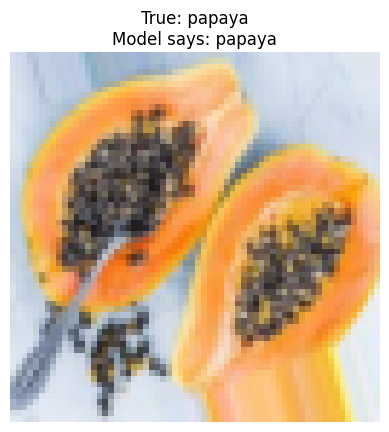

In [30]:
def check_random_image():
    model.eval()
    random_index = np.random.randint(len(test_dataset))

    image, true_label = test_dataset[random_index]

    image_input = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(image_input)
        _, predicted_class = torch.max(output, 1)

    predicted_name = test_dataset.classes[predicted_class.item()]
    true_name = test_dataset.classes[true_label]

    image_show = image.permute(1, 2, 0) * 0.5 + 0.5
    plt.imshow(image_show)
    plt.title(f"True: {true_name}\nModel says: {predicted_name}")
    plt.axis("off")
    plt.show()

check_random_image()